# 06 — Validación Clínica de las Bandas

**Fase 1F.** En el conjunto **TEST** (held-out) verificamos si las bandas tienen significado clínico real: prevalencia, **odds ratio** y **riesgo relativo** por banda, y sensibilidad/especificidad/PPV/NPV de cada umbral.

In [1]:
# --- Setup: rutas y utilidades de presentación ---
import sys, json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display, Markdown

BR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(BR / "src"))
sys.path.insert(0, str(BR.parent / "src"))
from predia_brfss import config, codebook

RES = BR / "results"
def show(p, w=None):
    display(Image(filename=str(p), width=w))
def table(csv, **kw):
    return pd.read_csv(csv, **kw)
def load(j):
    return json.load(open(j))
pd.set_option("display.max_columns", 40)
print("Entorno listo:", BR)


Entorno listo: /home/wowo/Descargas/predia/ml-research/brfss


## Bandas en TEST: prevalencia y asociación (vs banda Bajo)

,band,action,n,cases,observed_prevalence,odds_ratio_vs_bajo,or_ci95,relative_risk_vs_bajo,rr_ci95
0,Bajo,Seguimiento normal,26149,764,0.0292,1.000,"[1.0, 1.0]",1.000,"[1.0, 1.0]"
1,Moderado,Educación y cambios de hábitos,11877,1683,0.1417,5.486,"[5.021, 5.993]",4.850,"[4.465, 5.268]"
2,Alto,Evaluación clínica prioritaria,7844,2285,0.2913,13.658,"[12.521, 14.898]",9.970,"[9.223, 10.778]"
3,Muy Alto,Referencia médica inmediata,4866,2337,0.4803,30.704,"[28.024, 33.64]",16.438,"[15.239, 17.731]"


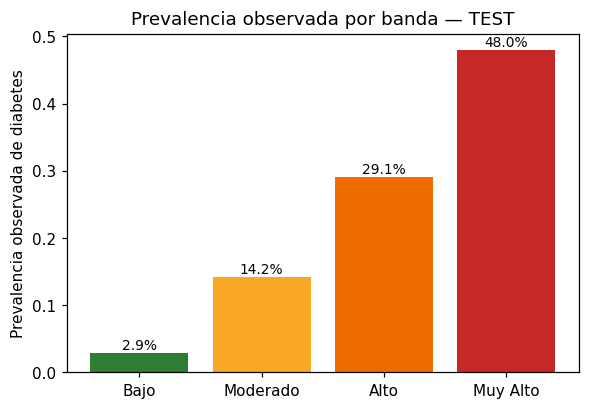

In [2]:
cv = load(RES/'clinical'/'clinical_validation.json')
display(table(RES/'clinical'/'band_association_test.csv'))
show(RES/'clinical'/'band_prevalence_test.png')

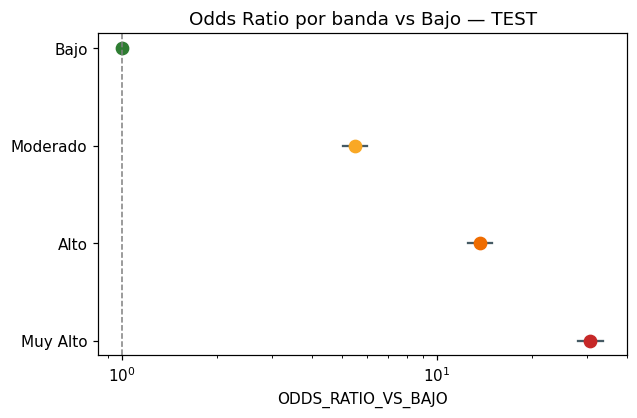

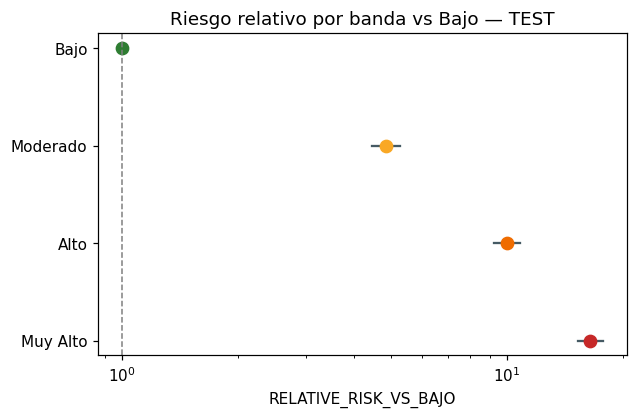

In [3]:
show(RES/'clinical'/'forest_or.png')
show(RES/'clinical'/'forest_rr.png')

## Puntos de operación clínica (cribado ≥ umbral)

In [4]:
table(RES/'clinical'/'operating_points_test.csv')

,decision,threshold,sensitivity,specificity,ppv,npv,lr_plus,flagged_pct
0,≥ Moderado,0.0909,0.8919,0.5813,0.2564,0.9708,2.130,48.46
1,≥ Alto,0.2000,0.6538,0.8148,0.3637,0.9356,3.530,25.05
2,≥ Muy Alto,0.4000,0.3306,0.9421,0.4803,0.8968,5.708,9.59


## Veredicto

In [5]:
v = cv['verdict']
print('Monotonía de prevalencia:', v['monotonic_prevalence'])
print('OR creciente:', v['or_increasing'])
print(f"Prevalencia Bajo={v['prevalence_low_band']:.3f} -> "
      f"Muy Alto={v['prevalence_high_band']:.3f} (x{v['fold_increase_extreme']})")
print('CLÍNICAMENTE SIGNIFICATIVO:', v['clinically_meaningful'])

Monotonía de prevalencia: True
OR creciente: True
Prevalencia Bajo=0.029 -> Muy Alto=0.480 (x16.45)
CLÍNICAMENTE SIGNIFICATIVO: True


### Conclusiones Fase 1F
- Las bandas muestran **prevalencia creciente y monótona** y **OR/RR crecientes** con IC95% que no incluyen 1 en las bandas altas → separación clínica real.
- El umbral de inclusión ofrece alta especificidad (pocas falsas alarmas) y el de exclusión alta sensibilidad (capta a la mayoría de los casos).
- El framework está listo para integrarse en PREDIA como **motor de soporte a la decisión** (ver `risk_stratification_report.md`).